## New York City Taxi Fare Prediction

Project Outline
1. Download the dataset
2. Explore and analyze the dataset
3. Prepare dataset for machine learing training
4. Train harcoded and baseline model
5. Make predictions
6. Perform feature engineering
7. Train and evaluate models
8. Tune hyperparameters for the best models
9. Create and Test Prediction Logic
10. Document and publish project outline

## 1. Download the Dataset

- Install required libraries
- Download data from Kaggle
- View dataset files
- Load training set with Pandas
- Load test set with Pandas

### Install Required Libraries

In [1]:
pip install pandas numpy scikit-learn xgboost geopy --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install kaggle --quiet

Note: you may need to restart the kernel to use updated packages.


### Download data from Kaggle

!kaggle competitions download -c new-york-city-taxi-fare-prediction --force

I opted out of using the line above. The data was downloaded manually to circumvent access restrictions on my laptop

In [3]:
from pathlib import Path

data_dir = Path("C:/Users/JFADIPE/Downloads/John Fadipe - Software Engineering/Dataset/new-york-city-taxi-fare-prediction")

### View Dataset

In [4]:
!dir "{data_dir}"

 Volume in drive C has no label.
 Volume Serial Number is EEDD-BD71

 Directory of C:\Users\JFADIPE\Downloads\John Fadipe - Software Engineering\Dataset\new-york-city-taxi-fare-prediction

29-Jul-25  08:12 AM    <DIR>          .
29-Jul-25  08:12 AM    <DIR>          ..
29-Jul-25  08:11 AM               486 GCP-Coupons-Instructions.rtf
29-Jul-25  08:11 AM           343,271 sample_submission.csv
29-Jul-25  08:11 AM           983,020 test.csv
29-Jul-25  08:12 AM     5,697,178,298 train.csv
               4 File(s)  5,698,505,075 bytes
               2 Dir(s)  41,194,643,456 bytes free


In [5]:
file_path = fr"{data_dir}/train.csv"

line_count = 0
with open(file_path, 'r', encoding='utf-8') as file:
    for _ in file:
        line_count += 1

print(f"Total lines in train.csv: {line_count}")

Total lines in train.csv: 55423857


In [6]:
!find /v /c "" "{data_dir}/test.csv"


---------- C:\USERS\JFADIPE\DOWNLOADS\JOHN FADIPE - SOFTWARE ENGINEERING\DATASET\NEW-YORK-CITY-TAXI-FARE-PREDICTION/TEST.CSV: 9915


In [7]:
!find /v /c "" "{data_dir}/sample_submission.csv"


---------- C:\USERS\JFADIPE\DOWNLOADS\JOHN FADIPE - SOFTWARE ENGINEERING\DATASET\NEW-YORK-CITY-TAXI-FARE-PREDICTION/SAMPLE_SUBMISSION.CSV: 9915


In [8]:
!powershell -Command "Get-Content '{data_dir}/train.csv' -TotalCount 10"

key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.84161,40.712278,1
2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1
2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.76127,-73.991242,40.750562,2
2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42 UTC,-73.98713,40.733143,-73.991567,40.758092,1
2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1
2011-01-06 09:50:45.0000002,12.1,2011-01-06 09:50:45 UTC,-74.000964,40.73163,-73.972892,40.758233,1
2012-11-20 20:35:00.0000001,7.5,2012-11-20 20:35:00 UTC,-73.980002,40.751662,-73.973802,40.764842,1
2012-01-04 17:22:00.00000081,16.5,2012-01-04 17:22:00 UTC,-73.9513,40.774138,-73.990095,40.751048,1
2012-12-03 13:10:00.000000125,9,2012-12-03 13:10:00 UTC,-74.006462,40.726713,-73.99

In [9]:
!powershell -Command "Get-Content '{data_dir}/test.csv' -TotalCount 10"

key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
2015-01-27 13:08:24.0000002,2015-01-27 13:08:24 UTC,-73.973320007324219,40.7638053894043,-73.981430053710938,40.74383544921875,1
2015-01-27 13:08:24.0000003,2015-01-27 13:08:24 UTC,-73.986862182617188,40.719383239746094,-73.998886108398438,40.739200592041016,1
2011-10-08 11:53:44.0000002,2011-10-08 11:53:44 UTC,-73.982524,40.75126,-73.979654,40.746139,1
2012-12-01 21:12:12.0000002,2012-12-01 21:12:12 UTC,-73.98116,40.767807,-73.990448,40.751635,1
2012-12-01 21:12:12.0000003,2012-12-01 21:12:12 UTC,-73.966046,40.789775,-73.988565,40.744427,1
2012-12-01 21:12:12.0000005,2012-12-01 21:12:12 UTC,-73.960983,40.765547,-73.979177,40.740053,1
2011-10-06 12:10:20.0000001,2011-10-06 12:10:20 UTC,-73.949013,40.773204,-73.959622,40.770893,1
2011-10-06 12:10:20.0000003,2011-10-06 12:10:20 UTC,-73.777282,40.646636,-73.985083,40.759368,1
2011-10-06 12:10:20.0000002,2011-10-06 12:10:20 UTC,-74.01409

In [10]:
!powershell -Command "Get-Content '{data_dir}/sample_submission.csv' -TotalCount 10"

key,fare_amount
2015-01-27 13:08:24.0000002,11.35
2015-01-27 13:08:24.0000003,11.35
2011-10-08 11:53:44.0000002,11.35
2012-12-01 21:12:12.0000002,11.35
2012-12-01 21:12:12.0000003,11.35
2012-12-01 21:12:12.0000005,11.35
2011-10-06 12:10:20.0000001,11.35
2011-10-06 12:10:20.0000003,11.35
2011-10-06 12:10:20.0000002,11.35


#### Observations:

- This is a supervised learning regression problem
- Training data is 5.5 GB in size
- Training data has 5.5 million rows
- Test set is much smaller (< 10,000 rows)
- The training set has 8 columns:
    - `key` (a unique identifier)
    - `fare_amount` (target column)
    - `pickup_datetime`
    - `pickup_longitude`
    - `pickup_latitude`
    - `dropoff_longitude`
    - `dropoff_latitude`
    - `passenger_count`
- The test set has all columns except the target column `fare_amount`.
- The submission file should contain the `key` and `fare_amount` for each test sample.

### Loading Training Set

Loading the entire dataset into Pandas is not optimal, so the following optimizations were adopted:

- Ignored the `key` column
- Parsed pickup datetime while loading data 
- Specified data types for other columns
   - `float32` for geo coordinates
   - `float32` for fare amount
   - `uint8` for passenger count
- Worked with a 1% sample of the data (~500k rows)

In [11]:
import pandas as pd

In [12]:
selected_columns = "fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count".split(",")

In [13]:
selected_columns

['fare_amount',
 'pickup_datetime',
 'pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'passenger_count']

In [14]:
data_types = {
     "fare_amount": "float32",
     "pickup_longitude": "float32",
     "pickup_latitude": "float32",
     "dropoff_longitude": "float32",
     "dropoff_latitude": "float32",
     "passenger_count": "uint8"
}

data_types

{'fare_amount': 'float32',
 'pickup_longitude': 'float32',
 'pickup_latitude': 'float32',
 'dropoff_longitude': 'float32',
 'dropoff_latitude': 'float32',
 'passenger_count': 'uint8'}

In [15]:
sample_fraction = 0.01

In [16]:
%%time
import random

def skip_row(row_index):
    if row_index == 0:
        return False
    return random.random() > sample_fraction

random.seed(42)
df = pd.read_csv(data_dir/"train.csv", 
                 usecols = selected_columns, 
                 dtype = data_types, 
                 parse_dates = ["pickup_datetime"], 
                 skiprows = skip_row)

CPU times: total: 42.8 s
Wall time: 43.1 s


### Load Test Set

In [17]:
test_df = pd.read_csv(data_dir/"test.csv", dtype = data_types, parse_dates = ["pickup_datetime"])

In [18]:
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,4.0,2014-12-06 20:36:22+00:00,-73.979813,40.751904,-73.979446,40.755482,1
1,8.0,2013-01-17 17:22:00+00:00,0.000000,0.000000,0.000000,0.000000,2
2,8.9,2011-06-15 18:07:00+00:00,-73.996330,40.753223,-73.978897,40.766964,3
3,6.9,2009-12-14 12:33:00+00:00,-73.982430,40.745747,-73.982430,40.745747,1
4,7.0,2013-11-06 11:26:54+00:00,-73.959061,40.781059,-73.962059,40.768604,1
...,...,...,...,...,...,...,...
552445,45.0,2014-02-06 23:59:45+00:00,-73.973587,40.747669,-73.999916,40.602894,1
552446,22.5,2015-01-05 15:29:08+00:00,-73.935928,40.799656,-73.985710,40.726952,2
552447,4.5,2013-02-17 22:27:00+00:00,-73.992531,40.748619,-73.998436,40.740143,1
552448,14.5,2013-01-27 12:41:00+00:00,-74.012115,40.706635,-73.988724,40.756218,1


In [19]:
test_df

,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2015-01-27 13:08:24.0000002,2015-01-27 13:08:24+00:00,-73.973320,40.763805,-73.981430,40.743835,1
1,2015-01-27 13:08:24.0000003,2015-01-27 13:08:24+00:00,-73.986862,40.719383,-73.998886,40.739201,1
2,2011-10-08 11:53:44.0000002,2011-10-08 11:53:44+00:00,-73.982521,40.751259,-73.979652,40.746140,1
3,2012-12-01 21:12:12.0000002,2012-12-01 21:12:12+00:00,-73.981163,40.767807,-73.990448,40.751637,1
4,2012-12-01 21:12:12.0000003,2012-12-01 21:12:12+00:00,-73.966049,40.789776,-73.988564,40.744427,1
...,...,...,...,...,...,...,...
9909,2015-05-10 12:37:51.0000002,2015-05-10 12:37:51+00:00,-73.968124,40.796997,-73.955643,40.780388,6
9910,2015-01-12 17:05:51.0000001,2015-01-12 17:05:51+00:00,-73.945511,40.803600,-73.960213,40.776371,6
9911,2015-04-19 20:44:15.0000001,2015-04-19 20:44:15+00:00,-73.991600,40.726608,-73.789742,40.647011,6
9912,2015-01-31 01:05:19.0000005,2015-01-31 01:05:19+00:00,-73.985573,40.735432,-73.939178,40.801731,6


## 2. Explore the Dataset

- Basic info about training set
- Basic info about test set
- Exploratory data analysis & visualization
- Ask & answer questions

### Training set

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 552450 entries, 0 to 552449
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   fare_amount        552450 non-null  float32            
 1   pickup_datetime    552450 non-null  datetime64[ns, UTC]
 2   pickup_longitude   552450 non-null  float32            
 3   pickup_latitude    552450 non-null  float32            
 4   dropoff_longitude  552450 non-null  float32            
 5   dropoff_latitude   552450 non-null  float32            
 6   passenger_count    552450 non-null  uint8              
dtypes: datetime64[ns, UTC](1), float32(5), uint8(1)
memory usage: 15.3 MB


In [21]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,552450.000000,552450.000000,552450.000000,552450.000000,552450.000000,552450.000000
mean,11.354059,-72.497063,39.910500,-72.504326,39.934265,1.684983
std,9.811924,11.618246,8.061114,12.074346,9.255058,1.337664
min,-52.000000,-1183.362793,-3084.490234,-3356.729736,-2073.150635,0.000000
25%,6.000000,-73.992020,40.734875,-73.991425,40.733990,1.000000
50%,8.500000,-73.981819,40.752621,-73.980179,40.753101,1.000000
75%,12.500000,-73.967155,40.767036,-73.963737,40.768059,2.000000
max,499.000000,2420.209473,404.983337,2467.752686,3351.403076,208.000000


In [22]:
df["pickup_datetime"].min(), df["pickup_datetime"].max()

(Timestamp('2009-01-01 00:11:46+0000', tz='UTC'),
 Timestamp('2015-06-30 23:59:54+0000', tz='UTC'))

Observations about training data:

- 550k+ rows, as expected
- No missing data (in the sample)
- `fare_amount` ranges from \$-52.0 to \$499.0 
- `passenger_count` ranges from 0 to 208 
- There seem to be some errors in the latitude & longitude values
- Dates range from 1st Jan 2009 to 30th June 2015
- The dataset takes up 15 MB of space in the RAM

We may need to deal with outliers and data entry errors before we train our model.

### Test Set

In [23]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9914 entries, 0 to 9913
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   key                9914 non-null   object             
 1   pickup_datetime    9914 non-null   datetime64[ns, UTC]
 2   pickup_longitude   9914 non-null   float32            
 3   pickup_latitude    9914 non-null   float32            
 4   dropoff_longitude  9914 non-null   float32            
 5   dropoff_latitude   9914 non-null   float32            
 6   passenger_count    9914 non-null   uint8              
dtypes: datetime64[ns, UTC](1), float32(4), object(1), uint8(1)
memory usage: 319.6+ KB


In [24]:
test_df.describe()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000
mean,-73.974716,40.751041,-73.973656,40.751740,1.671273
std,0.042774,0.033541,0.039072,0.035435,1.278747
min,-74.252190,40.573143,-74.263245,40.568974,1.000000
25%,-73.992500,40.736125,-73.991249,40.735253,1.000000
50%,-73.982327,40.753052,-73.980015,40.754065,1.000000
75%,-73.968012,40.767113,-73.964062,40.768757,2.000000
max,-72.986534,41.709557,-72.990967,41.696682,6.000000


In [25]:
test_df["pickup_datetime"].min(), test_df["pickup_datetime"].max()

(Timestamp('2009-01-01 11:04:24+0000', tz='UTC'),
 Timestamp('2015-06-30 20:03:50+0000', tz='UTC'))

Some observations about the test set:

- 9914 rows of data
- No missing values
- No obvious data entry errors
- 1 to 6 passengers (we can limit training data to this range)
- Latitudes lie between 40 and 42
- Longitudes lie between -75 and -72
- Pickup dates range from Jan 1st 2009 to Jun  30th 2015 (same as training set)

We can use the ranges of the test set to drop outliers/invalid data from the training set.

## 3. Prepare Dataset for Training

- Split Training & Validation Set
- Fill/Remove Missing Values
- Extract Inputs & Outputs
   - Training
   - Validation
   - Test

### Split Training & Validation Set

We'll set aside 20% of the training data as the validation set, to evaluate the models we train on previously unseen data. 

Since the test set and training set have the same date ranges, we can pick a random 20% fraction.

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
train_df, validation_df = train_test_split(df, test_size = 0.2, random_state = 42)

In [28]:
len(train_df), len(validation_df)

(441960, 110490)

### Fill/Remove Missing Values

There are no missing values in the sample, but if there were, the best course of action would be to drop the rows with missing values instead of trying to fill them (since the training data is quite large)

The code below would have been used for dropping the rows

train_df = train_df.dropna()

validation_df = validation_df.dropna()

### Extract Inputs and Outputs

In [29]:
train_df.columns

Index(['fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count'],
      dtype='object')

In [30]:
input_columns = ["pickup_longitude", "pickup_latitude", "dropoff_longitude",
                 "dropoff_latitude", "passenger_count"]

In [31]:
target_column = "fare_amount"

### Training

In [32]:
train_inputs = train_df[input_columns]
train_target = train_df[target_column]

In [33]:
train_inputs

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
353352,-73.993652,40.741543,-73.977974,40.742352,4
360070,-73.993805,40.724579,-73.993805,40.724579,1
372609,-73.959160,40.780750,-73.969116,40.761230,1
550895,-73.952187,40.783951,-73.978645,40.772602,1
444151,-73.977112,40.746834,-73.991104,40.750404,2
...,...,...,...,...,...
110268,-73.987152,40.750633,-73.979073,40.763168,1
259178,-73.972656,40.764042,-74.013176,40.707840,2
365838,-73.991982,40.749767,-73.989845,40.720551,3
131932,-73.969055,40.761398,-73.990814,40.751328,1


In [34]:
train_target

353352     6.0
360070     3.7
372609    10.0
550895     8.9
444151     7.3
          ... 
110268     9.3
259178    18.5
365838    10.1
131932    10.9
121958     9.5
Name: fare_amount, Length: 441960, dtype: float32

### Validation

In [35]:
validation_inputs = validation_df[input_columns]
validation_target = validation_df[target_column]

In [36]:
validation_inputs

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
15971,-73.995834,40.759190,-73.973679,40.739086,1
149839,-73.977386,40.738335,-73.976143,40.751205,1
515867,-73.983910,40.749470,-73.787170,40.646645,1
90307,-73.790794,40.643463,-73.972252,40.690182,1
287032,-73.976593,40.761944,-73.991463,40.750309,2
...,...,...,...,...,...
467556,-73.968567,40.761238,-73.983406,40.750019,3
19482,-73.986725,40.755920,-73.985855,40.731171,1
186063,0.000000,0.000000,0.000000,0.000000,1
382260,-73.980057,40.760334,-73.872589,40.774300,1


In [37]:
validation_target

15971     14.000000
149839     6.500000
515867    49.570000
90307     49.700001
287032     8.500000
            ...    
467556     6.100000
19482      7.300000
186063     4.500000
382260    32.900002
18838     11.500000
Name: fare_amount, Length: 110490, dtype: float32

In [38]:
test_inputs = test_df[input_columns]

In [39]:
test_inputs

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,-73.973320,40.763805,-73.981430,40.743835,1
1,-73.986862,40.719383,-73.998886,40.739201,1
2,-73.982521,40.751259,-73.979652,40.746140,1
3,-73.981163,40.767807,-73.990448,40.751637,1
4,-73.966049,40.789776,-73.988564,40.744427,1
...,...,...,...,...,...
9909,-73.968124,40.796997,-73.955643,40.780388,6
9910,-73.945511,40.803600,-73.960213,40.776371,6
9911,-73.991600,40.726608,-73.789742,40.647011,6
9912,-73.985573,40.735432,-73.939178,40.801731,6


## 4. Train Hardcoded & Baseline Models

- Hardcoded model: always predict average fare
- Baseline model: Linear regression 

### Train & Evaluate Hardcoded Model

Creating a simple model that always predicts the average.

In [40]:
import numpy as np

In [41]:
class MeanRegressor:
    def fit(self, inputs, targets):
        self.mean = targets.mean()
    
    def predict(self, inputs):
        return np.full(inputs.shape[0], self.mean)

In [42]:
mean_model = MeanRegressor()

In [43]:
mean_model.fit(train_inputs, train_target)

In [44]:
mean_model.mean

np.float32(11.354714)

In [45]:
train_predictions = mean_model.predict(train_inputs)
train_predictions

array([11.354714, 11.354714, 11.354714, ..., 11.354714, 11.354714,
       11.354714], shape=(441960,), dtype=float32)

In [46]:
train_target

353352     6.0
360070     3.7
372609    10.0
550895     8.9
444151     7.3
          ... 
110268     9.3
259178    18.5
365838    10.1
131932    10.9
121958     9.5
Name: fare_amount, Length: 441960, dtype: float32

In [47]:
validation_predictions = mean_model.predict(validation_inputs)
validation_predictions

array([11.354714, 11.354714, 11.354714, ..., 11.354714, 11.354714,
       11.354714], shape=(110490,), dtype=float32)

In [48]:
validation_target

15971     14.000000
149839     6.500000
515867    49.570000
90307     49.700001
287032     8.500000
            ...    
467556     6.100000
19482      7.300000
186063     4.500000
382260    32.900002
18838     11.500000
Name: fare_amount, Length: 110490, dtype: float32

In [49]:
from sklearn.metrics import mean_squared_error

In [50]:
train_rmse = np.sqrt(mean_squared_error(train_target, train_predictions))
train_rmse

np.float64(9.789781840838485)

In [51]:
validation_rmse = np.sqrt(mean_squared_error(train_target, train_predictions))
validation_rmse

np.float64(9.789781840838485)

### Train & Evaluate Baseline Model

In [52]:
from sklearn.linear_model import LinearRegression

In [53]:
linear_reg_model = LinearRegression()

In [54]:
linear_reg_model.fit(train_inputs, train_target)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [55]:
train_predictions = linear_reg_model.predict(train_inputs)
train_predictions

array([11.546237, 11.28461 , 11.28414 , ..., 11.458918, 11.284281,
       11.284448], shape=(441960,), dtype=float32)

In [56]:
train_target

353352     6.0
360070     3.7
372609    10.0
550895     8.9
444151     7.3
          ... 
110268     9.3
259178    18.5
365838    10.1
131932    10.9
121958     9.5
Name: fare_amount, Length: 441960, dtype: float32

In [57]:
np.sqrt(mean_squared_error(train_predictions, train_target))

np.float64(9.788632662774626)

The hard-coded model is off by 9.79 on average, while the average fare is 11.35.

## 5. Make Predictions

- Make predictions for test set
- Record in experiment tracking sheet

In [58]:
test_predictions = linear_reg_model.predict(test_inputs)

In [59]:
test_predictions

array([11.28428  , 11.284634 , 11.284384 , ..., 11.721249 , 11.7207985,
       11.720594 ], shape=(9914,), dtype=float32)

In [60]:
#Submit model to Kaggle to check accuracy
submission_df = pd.read_csv(data_dir/"sample_submission.csv")
submission_df

,key,fare_amount
0,2015-01-27 13:08:24.0000002,11.35
1,2015-01-27 13:08:24.0000003,11.35
2,2011-10-08 11:53:44.0000002,11.35
3,2012-12-01 21:12:12.0000002,11.35
4,2012-12-01 21:12:12.0000003,11.35
...,...,...
9909,2015-05-10 12:37:51.0000002,11.35
9910,2015-01-12 17:05:51.0000001,11.35
9911,2015-04-19 20:44:15.0000001,11.35
9912,2015-01-31 01:05:19.0000005,11.35


In [61]:
submission_df["fare_amount"] = test_predictions
submission_df

,key,fare_amount
0,2015-01-27 13:08:24.0000002,11.284280
1,2015-01-27 13:08:24.0000003,11.284634
2,2011-10-08 11:53:44.0000002,11.284384
3,2012-12-01 21:12:12.0000002,11.284222
4,2012-12-01 21:12:12.0000003,11.284050
...,...,...
9909,2015-05-10 12:37:51.0000002,11.720277
9910,2015-01-12 17:05:51.0000001,11.720225
9911,2015-04-19 20:44:15.0000001,11.721249
9912,2015-01-31 01:05:19.0000005,11.720798


In [62]:
import os

os.makedirs("Kaggle Submission", exist_ok = True)
submission_df.to_csv("Kaggle Submission/Linear_Model_Submission.csv", index = None)

In [63]:
#Function to make submissions easier

def generate_submission(test_predictions, fname):
    submission_df = pd.read_csv(pd.read_csv(data_dir/"sample_submission.csv"))
    submission_df["fare_amount"] = test_predictions
    submission_df.to_csv(fname, index = None)

## 6. Feature Engineering


- Extract parts of date
- Remove outliers & invalid data
- Add distance between pickup & drop
- Add distance from landmarks


### Extract Parts of Date

- Year
- Month
- Day
- Weekday
- Hour

In [64]:
def add_dateparts(df, column):
    df[column + "_year"] = df[column].dt.year
    df[column + "_month"] = df[column].dt.month
    df[column + "_day"] = df[column].dt.day
    df[column + "_weekday"] = df[column].dt.weekday
    df[column + "_hour"] = df[column].dt.hour

In [65]:
add_dateparts(train_df, "pickup_datetime")

In [66]:
add_dateparts(validation_df, "pickup_datetime")

In [67]:
add_dateparts(test_df, "pickup_datetime")

In [68]:
train_df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour
353352,6.0,2015-04-12 03:40:38+00:00,-73.993652,40.741543,-73.977974,40.742352,4,2015,4,12,6,3
360070,3.7,2011-01-26 19:21:00+00:00,-73.993805,40.724579,-73.993805,40.724579,1,2011,1,26,2,19
372609,10.0,2012-10-03 10:40:17+00:00,-73.959160,40.780750,-73.969116,40.761230,1,2012,10,3,2,10
550895,8.9,2012-03-14 13:44:27+00:00,-73.952187,40.783951,-73.978645,40.772602,1,2012,3,14,2,13
444151,7.3,2012-02-05 15:33:00+00:00,-73.977112,40.746834,-73.991104,40.750404,2,2012,2,5,6,15
...,...,...,...,...,...,...,...,...,...,...,...,...
110268,9.3,2009-09-06 16:12:00+00:00,-73.987152,40.750633,-73.979073,40.763168,1,2009,9,6,6,16
259178,18.5,2009-04-12 09:58:56+00:00,-73.972656,40.764042,-74.013176,40.707840,2,2009,4,12,6,9
365838,10.1,2012-07-12 19:30:00+00:00,-73.991982,40.749767,-73.989845,40.720551,3,2012,7,12,3,19
131932,10.9,2011-02-17 18:33:00+00:00,-73.969055,40.761398,-73.990814,40.751328,1,2011,2,17,3,18


In [69]:
test_df

,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour
0,2015-01-27 13:08:24.0000002,2015-01-27 13:08:24+00:00,-73.973320,40.763805,-73.981430,40.743835,1,2015,1,27,1,13
1,2015-01-27 13:08:24.0000003,2015-01-27 13:08:24+00:00,-73.986862,40.719383,-73.998886,40.739201,1,2015,1,27,1,13
2,2011-10-08 11:53:44.0000002,2011-10-08 11:53:44+00:00,-73.982521,40.751259,-73.979652,40.746140,1,2011,10,8,5,11
3,2012-12-01 21:12:12.0000002,2012-12-01 21:12:12+00:00,-73.981163,40.767807,-73.990448,40.751637,1,2012,12,1,5,21
4,2012-12-01 21:12:12.0000003,2012-12-01 21:12:12+00:00,-73.966049,40.789776,-73.988564,40.744427,1,2012,12,1,5,21
...,...,...,...,...,...,...,...,...,...,...,...,...
9909,2015-05-10 12:37:51.0000002,2015-05-10 12:37:51+00:00,-73.968124,40.796997,-73.955643,40.780388,6,2015,5,10,6,12
9910,2015-01-12 17:05:51.0000001,2015-01-12 17:05:51+00:00,-73.945511,40.803600,-73.960213,40.776371,6,2015,1,12,0,17
9911,2015-04-19 20:44:15.0000001,2015-04-19 20:44:15+00:00,-73.991600,40.726608,-73.789742,40.647011,6,2015,4,19,6,20
9912,2015-01-31 01:05:19.0000005,2015-01-31 01:05:19+00:00,-73.985573,40.735432,-73.939178,40.801731,6,2015,1,31,5,1


### Add Distance Between Pickup and Drop

I am using the haversine distance: 
- https://en.wikipedia.org/wiki/Haversine_formula
- https://stackoverflow.com/questions/29545704/fast-haversine-approximation-python-pandas

In [70]:
import numpy as np

def haversine_np(long1, lat1, long2, lat2):
    """
    Calculate the great circle distance between two points
    on the earth (specified in decimal degrees)

    All args must be of equal length.    

    """
    long1, lat1, long2, lat2 = map(np.radians, [long1, lat1, long2, lat2])

    drop_long = long2 - long1
    drop_lat = lat2 - lat1

    a = np.sin(drop_lat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(drop_long/2.0)**2

    c = 2 * np.arcsin(np.sqrt(a))
    km = 6367 * c
    return km

In [71]:
def add_trip_distance(df):
    df["trip_distance"] = haversine_np(df["pickup_longitude"],
                                       df["pickup_latitude"],
                                       df["dropoff_longitude"],
                                       df["dropoff_latitude"])

In [72]:
add_trip_distance(train_df)

In [73]:
add_trip_distance(validation_df)

In [74]:
add_trip_distance(test_df)

In [75]:
train_df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,trip_distance
353352,6.0,2015-04-12 03:40:38+00:00,-73.993652,40.741543,-73.977974,40.742352,4,2015,4,12,6,3,1.323411
360070,3.7,2011-01-26 19:21:00+00:00,-73.993805,40.724579,-73.993805,40.724579,1,2011,1,26,2,19,0.000000
372609,10.0,2012-10-03 10:40:17+00:00,-73.959160,40.780750,-73.969116,40.761230,1,2012,10,3,2,10,2.325504
550895,8.9,2012-03-14 13:44:27+00:00,-73.952187,40.783951,-73.978645,40.772602,1,2012,3,14,2,13,2.558912
444151,7.3,2012-02-05 15:33:00+00:00,-73.977112,40.746834,-73.991104,40.750404,2,2012,2,5,6,15,1.243267
...,...,...,...,...,...,...,...,...,...,...,...,...,...
110268,9.3,2009-09-06 16:12:00+00:00,-73.987152,40.750633,-73.979073,40.763168,1,2009,9,6,6,16,1.549976
259178,18.5,2009-04-12 09:58:56+00:00,-73.972656,40.764042,-74.013176,40.707840,2,2009,4,12,6,9,7.116529
365838,10.1,2012-07-12 19:30:00+00:00,-73.991982,40.749767,-73.989845,40.720551,3,2012,7,12,3,19,3.251601
131932,10.9,2011-02-17 18:33:00+00:00,-73.969055,40.761398,-73.990814,40.751328,1,2011,2,17,3,18,2.146101


### Add Distance From Popular Landmarks

- JFK Airport
- LGA Airport
- EWR Airport
- Times Square
- Met Meuseum
- World Trade Center

Adding the distance from drop location. 

In [76]:
jfk_longlat = -73.7781, 40.6413
lga_longlat = -73.8740, 40.7769
ewr_longlat = -74.1745, 40.6895
met_longlat = -73.9632, 40.7794
wtc_longlat = -74.0099, 40.7126

In [77]:
def add_landmark_dropoff_distance(df, landmark_name, landmark_longlat):
    long, lat = landmark_longlat
    df[landmark_name + "_drop_distance"] = haversine_np(long, lat, df["dropoff_longitude"],
                                                        df["dropoff_latitude"])

In [78]:
%%time
for a_df in [train_df, validation_df, test_df]:
    for name, longlat in [('jfk', jfk_longlat), ('lga', lga_longlat),
                          ('ewr', ewr_longlat), ('met', met_longlat),
                          ('wtc', wtc_longlat)]:
        add_landmark_dropoff_distance(a_df, name, longlat)

CPU times: total: 141 ms
Wall time: 149 ms


In [79]:
train_df.sample(5)

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,trip_distance,jfk_drop_distance,lga_drop_distance,ewr_drop_distance,met_drop_distance,wtc_drop_distance
248580,16.1,2012-05-02 11:10:08+00:00,-73.959312,40.780312,-73.987213,40.760117,1,2012,5,2,2,11,3.247971,22.015882,9.708694,17.617218,2.945082,5.615404
501388,7.3,2009-08-06 06:26:07+00:00,-73.974586,40.778271,-73.958488,40.765560,1,2009,8,6,3,6,1.957222,20.533411,7.221197,20.058718,1.588069,7.305805
195013,12.0,2014-02-02 17:47:00+00:00,-73.969460,40.793446,-73.932289,40.800362,1,2014,2,2,6,17,3.219971,21.933372,5.554118,23.824432,3.491500,11.738447
354756,10.5,2012-04-27 01:22:59+00:00,-73.983238,40.738655,-73.947586,40.779556,1,2012,4,27,4,1,5.446352,20.972895,6.198837,21.569593,1.314549,9.104286
285203,7.7,2009-05-17 14:57:04+00:00,-73.946182,40.792313,-73.967690,40.762695,1,2009,5,17,6,14,3.755900,20.906881,8.041292,19.222290,1.894177,6.604736


### Remove Outliers and Invalid Data

There seems to be some invalide data in each of the following columns:

- Fare amount
- Passenger count
- Pickup latitude & longitude
- Drop latitude & longitude

In [80]:
train_df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,trip_distance,jfk_drop_distance,lga_drop_distance,ewr_drop_distance,met_drop_distance,wtc_drop_distance
count,441960.000000,441960.000000,441960.000000,441960.000000,441960.000000,441960.000000,441960.000000,441960.000000,441960.000000,441960.000000,441960.000000,441960.000000,441960.000000,441960.000000,441960.000000,441960.000000,441960.000000
mean,11.354714,-72.498627,39.909996,-72.508141,39.937862,1.684444,2011.740038,6.263920,15.732492,3.035813,13.506568,19.751762,193.148026,182.365189,191.412308,177.416016,178.902069
std,9.789793,11.795325,8.464263,12.398610,9.857421,1.344170,1.857024,3.434881,8.697374,1.950033,6.517710,371.299316,1223.614746,1226.672119,1228.515259,1228.388794,1228.487183
min,-52.000000,-1183.362793,-3084.490234,-3356.729736,-2073.150635,0.000000,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.305583,0.116402,0.129245,0.031195,0.009281
25%,6.000000,-73.992027,40.734859,-73.991409,40.733967,1.000000,2010.000000,3.000000,8.000000,1.000000,9.000000,1.212447,20.535247,8.350981,16.502820,2.169769,3.642480
50%,8.500000,-73.981819,40.752613,-73.980171,40.753078,1.000000,2012.000000,6.000000,16.000000,3.000000,14.000000,2.116254,21.202131,9.575539,18.016346,3.817937,5.559632
75%,12.500000,-73.967186,40.767006,-73.963715,40.768044,2.000000,2013.000000,9.000000,23.000000,5.000000,19.000000,3.879624,21.948318,11.122054,19.953297,6.071617,7.814558
max,400.000000,2420.209473,404.899994,2467.752686,3351.403076,208.000000,2015.000000,12.000000,31.000000,6.000000,23.000000,16913.427734,15057.673828,15074.642578,15074.713867,15077.615234,15072.110352


In [81]:
test_df.describe()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,trip_distance,jfk_drop_distance,lga_drop_distance,ewr_drop_distance,met_drop_distance,wtc_drop_distance
count,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000
mean,-73.974716,40.751041,-73.973656,40.751740,1.671273,2011.815816,6.857979,16.194170,2.852834,13.467420,3.433216,20.916754,9.675180,18.546659,4.512898,6.037652
std,0.042774,0.033541,0.039072,0.035435,1.278747,1.803347,3.353272,8.838482,1.994451,6.868584,3.969883,3.303943,3.295647,4.035820,4.018428,4.252539
min,-74.252190,40.573143,-74.263245,40.568974,1.000000,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.401900,0.285629,0.284680,0.085747,0.040269
25%,-73.992500,40.736125,-73.991249,40.735253,1.000000,2010.000000,4.000000,9.000000,1.000000,8.000000,1.297261,20.513337,8.311565,16.520517,2.126287,3.670107
50%,-73.982327,40.753052,-73.980015,40.754065,1.000000,2012.000000,7.000000,16.000000,3.000000,15.000000,2.215648,21.181472,9.477797,18.024350,3.698123,5.541466
75%,-73.968012,40.767113,-73.964062,40.768757,2.000000,2014.000000,10.000000,25.000000,5.000000,19.000000,4.043051,21.909794,10.965272,19.880536,5.922544,7.757612
max,-72.986534,41.709557,-72.990967,41.696682,6.000000,2015.000000,12.000000,31.000000,6.000000,23.000000,99.933281,134.497726,126.062576,149.400787,130.347153,138.619492


To remove outliers the following ranges will be applied:

- `fare_amount`: 1  to  500
- `longitudes`: -75 to -72
- `latitudes`: 40 to 42
- `passenger_count`: 1 to 6

In [82]:
def remove_outliers(df):
    return df[(df["fare_amount"] >= 1.) & 
              (df["fare_amount"] <= 500.) &
              (df["pickup_longitude"] >= -75) & 
              (df["pickup_longitude"] <= -72) & 
              (df["dropoff_longitude"] >= -75) & 
              (df["dropoff_longitude"] <= -72) & 
              (df["pickup_latitude"] >= 40) & 
              (df["pickup_latitude"] <= 42) & 
              (df["dropoff_latitude"] >=40) & 
              (df["dropoff_latitude"] <= 42) & 
              (df["passenger_count"] >= 1) & 
              (df["passenger_count"] <= 6)]

In [83]:
train_df = remove_outliers(train_df)
train_df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,trip_distance,jfk_drop_distance,lga_drop_distance,ewr_drop_distance,met_drop_distance,wtc_drop_distance
353352,6.0,2015-04-12 03:40:38+00:00,-73.993652,40.741543,-73.977974,40.742352,4,2015,4,12,6,3,1.323411,20.241400,9.556355,17.564440,4.300385,4.261684
360070,3.7,2011-01-26 19:21:00+00:00,-73.993805,40.724579,-73.993805,40.724579,1,2011,1,26,2,19,0.000000,20.397520,11.641132,15.713149,6.614004,1.900218
372609,10.0,2012-10-03 10:40:17+00:00,-73.959160,40.780750,-73.969116,40.761230,1,2012,10,3,2,10,2.325504,20.894815,8.192266,19.044893,2.079418,6.402866
550895,8.9,2012-03-14 13:44:27+00:00,-73.952187,40.783951,-73.978645,40.772602,1,2012,3,14,2,13,2.558912,22.322773,8.819165,18.902145,1.503061,7.168338
444151,7.3,2012-02-05 15:33:00+00:00,-73.977112,40.746834,-73.991104,40.750404,2,2012,2,5,6,15,1.243267,21.658104,10.286617,16.863903,3.986955,4.489382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110268,9.3,2009-09-06 16:12:00+00:00,-73.987152,40.750633,-73.979073,40.763168,1,2009,9,6,6,16,1.549976,21.680714,8.973204,18.381714,2.244238,6.189971
259178,18.5,2009-04-12 09:58:56+00:00,-73.972656,40.764042,-74.013176,40.707840,2,2009,4,12,6,9,7.116529,21.146925,14.006921,13.743814,8.996409,0.596505
365838,10.1,2012-07-12 19:30:00+00:00,-73.991982,40.749767,-73.989845,40.720551,3,2012,7,12,3,19,3.251601,19.899387,11.589870,15.933608,6.913579,1.906144
131932,10.9,2011-02-17 18:33:00+00:00,-73.969055,40.761398,-73.990814,40.751328,1,2011,2,17,3,18,2.146101,21.695084,10.233944,16.927792,3.889789,4.594002


In [84]:
validation_df = remove_outliers(validation_df)
validation_df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,trip_distance,jfk_drop_distance,lga_drop_distance,ewr_drop_distance,met_drop_distance,wtc_drop_distance
15971,14.000000,2015-05-19 09:27:24+00:00,-73.995834,40.759190,-73.973679,40.739086,1,2015,5,19,1,9,2.909793,19.740025,9.383803,17.790024,4.565639,4.238884
149839,6.500000,2010-04-10 15:07:51+00:00,-73.977386,40.738335,-73.976143,40.751205,1,2010,4,10,5,15,1.433791,20.677670,9.058475,18.058867,3.316964,5.146432
515867,49.570000,2009-07-25 14:11:00+00:00,-73.983910,40.749470,-73.787170,40.646645,1,2009,7,25,5,14,20.132486,0.968338,16.217609,32.993080,20.916292,20.150650
90307,49.700001,2011-11-11 19:09:21+00:00,-73.790794,40.643463,-73.972252,40.690182,1,2011,11,11,4,19,16.152088,17.243528,12.700686,17.041767,9.943375,4.032990
287032,8.500000,2015-03-09 18:06:44+00:00,-73.976593,40.761944,-73.991463,40.750309,2,2015,3,9,0,18,1.799553,21.676977,10.318309,16.832249,4.013190,4.468960
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
506435,3.700000,2010-05-30 10:44:30+00:00,-73.959457,40.774727,-73.966301,40.772179,1,2010,5,30,6,10,0.641764,21.514425,7.784740,19.794155,0.843463,7.570518
467556,6.100000,2010-04-03 20:16:00+00:00,-73.968567,40.761238,-73.983406,40.750019,3,2010,4,3,5,20,1.764959,21.099281,9.680783,17.443117,3.681154,4.718924
19482,7.300000,2010-04-26 00:32:00+00:00,-73.986725,40.755920,-73.985855,40.731171,1,2010,4,26,0,0,2.751241,20.154758,10.699293,16.551817,5.688355,2.891594
382260,32.900002,2011-07-07 16:10:59+00:00,-73.980057,40.760334,-73.872589,40.774300,1,2011,7,7,3,16,9.176848,16.786745,0.312350,27.113701,7.646412,13.441156


In [85]:
os.makedirs("Parquet Folder", exist_ok = True)

In [86]:
train_df.to_parquet("Parquet Folder/train.parquet")

In [87]:
validation_df.to_parquet("Parquet Folder/validation.parquet")

## 7. Train & Evaluate Different Models

I'll train each of the following & submit predictions to Kaggle:

- Ridge Regression
- Random Forests
- Gradient Boosting

I'll also train models on the following as add-ons:
- Train Lasso
- SVM
- KNN
- Decision Tree models

### Split Inputs & Targets

In [88]:
train_df.columns

Index(['fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count',
       'pickup_datetime_year', 'pickup_datetime_month', 'pickup_datetime_day',
       'pickup_datetime_weekday', 'pickup_datetime_hour', 'trip_distance',
       'jfk_drop_distance', 'lga_drop_distance', 'ewr_drop_distance',
       'met_drop_distance', 'wtc_drop_distance'],
      dtype='object')

In [89]:
input_columns = [ 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count',
       'pickup_datetime_year', 'pickup_datetime_month', 'pickup_datetime_day',
       'pickup_datetime_weekday', 'pickup_datetime_hour', 'trip_distance',
       'jfk_drop_distance', 'lga_drop_distance', 'ewr_drop_distance',
       'met_drop_distance', 'wtc_drop_distance'] 

In [90]:
target_column = "fare_amount"

In [91]:
train_inputs = train_df[input_columns]
train_target = train_df[target_column]

In [92]:
validation_inputs = validation_df[input_columns]
validation_target = validation_df[target_column]

In [93]:
test_inputs = test_df[input_columns]

In [94]:
def evaluate(model):
    train_predictions = model.predict(train_inputs)
    train_rmse = np.sqrt(mean_squared_error(train_target, train_predictions))
    validation_predictions = model.predict(validation_inputs)
    validation_rmse = np.sqrt(mean_squared_error(validation_target, validation_predictions))
    return train_rmse, validation_rmse, train_predictions, validation_predictions

In [95]:
def predict_and_submit(model, fname):
    test_predictions = model.predict(test_inputs)
    submission_df = pd.read_csv(data_dir/"sample_submission.csv")
    submission_df["fare_amount"] = test_predictions
    submission_df.to_csv(fname, index=None)
    return submission_df

### Ridge Regression

In [96]:
from sklearn.linear_model import Ridge

In [97]:
model_1 = Ridge(random_state = 42, alpha = 0.9)

In [98]:
model_1.fit(train_inputs, train_target)

,alpha,0.9
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,42


In [99]:
evaluate(model_1)

(np.float64(5.049314043929337),
 np.float64(5.217845618612239),
 array([ 8.12923647,  4.11617242,  8.75016006, ..., 10.47209139,
         8.2307147 , 10.5869553 ], shape=(431098,)),
 array([10.91913868,  6.20507267, 46.2188478 , ...,  8.04612766,
        25.56777317,  8.45283364], shape=(107742,)))

The model trained on Ridge Regression was able to get to an RMSE of 5.2, much better than the baseline model.

In [100]:
predict_and_submit(model_1, "Kaggle Submission/Ridge_Model_Submission.csv")

,key,fare_amount
0,2015-01-27 13:08:24.0000002,10.081975
1,2015-01-27 13:08:24.0000003,11.400098
2,2011-10-08 11:53:44.0000002,5.356945
3,2012-12-01 21:12:12.0000002,8.763523
4,2012-12-01 21:12:12.0000003,14.609347
...,...,...
9909,2015-05-10 12:37:51.0000002,9.024146
9910,2015-01-12 17:05:51.0000001,11.217690
9911,2015-04-19 20:44:15.0000001,47.927670
9912,2015-01-31 01:05:19.0000005,22.600264


### Random Forest

In [101]:
from sklearn.ensemble import RandomForestRegressor

In [102]:
model_2 = RandomForestRegressor(random_state = 42, n_jobs = -1, max_depth = 10, n_estimators = 100)

In [103]:
%%time

model_2.fit(train_inputs, train_target)

CPU times: total: 12min 1s
Wall time: 1min 37s


,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [104]:
evaluate(model_2)

(np.float64(3.5947727467396025),
 np.float64(4.160784519860214),
 array([ 6.99399909,  9.09865173,  9.09379987, ..., 10.43082088,
         7.7821555 , 10.400694  ], shape=(431098,)),
 array([12.65433613,  6.14604627, 47.31069124, ...,  8.36589355,
        29.27069612,  8.24300598], shape=(107742,)))

In [105]:
predict_and_submit(model_2, "Kaggle Submission/RF_Model_Submission.csv")

,key,fare_amount
0,2015-01-27 13:08:24.0000002,10.479748
1,2015-01-27 13:08:24.0000003,10.468653
2,2011-10-08 11:53:44.0000002,5.046148
3,2012-12-01 21:12:12.0000002,8.481902
4,2012-12-01 21:12:12.0000003,14.300374
...,...,...
9909,2015-05-10 12:37:51.0000002,8.694722
9910,2015-01-12 17:05:51.0000001,12.535128
9911,2015-04-19 20:44:15.0000001,55.355344
9912,2015-01-31 01:05:19.0000005,21.467722


### Gradient Boosting

In [106]:
from xgboost import XGBRegressor

In [107]:
model_3 = XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror')

In [108]:
%%time

model_3.fit(train_inputs, train_target)

CPU times: total: 8.23 s
Wall time: 1.44 s


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [109]:
evaluate(model_3)

(np.float64(3.166428121984893),
 np.float64(3.979380031011537),
 array([ 6.653713 ,  8.931815 , 10.276588 , ..., 12.1582575,  9.564414 ,
         9.845059 ], shape=(431098,), dtype=float32),
 array([14.876896 ,  5.986584 , 47.171738 , ...,  7.5201406, 30.39466  ,
         8.515031 ], shape=(107742,), dtype=float32))

In [110]:
predict_and_submit(model_3, "Kaggle Submission/XGBoost_Model_Submission.csv")

,key,fare_amount
0,2015-01-27 13:08:24.0000002,10.819051
1,2015-01-27 13:08:24.0000003,11.724770
2,2011-10-08 11:53:44.0000002,4.443203
3,2012-12-01 21:12:12.0000002,9.096115
4,2012-12-01 21:12:12.0000003,16.050816
...,...,...
9909,2015-05-10 12:37:51.0000002,9.119739
9910,2015-01-12 17:05:51.0000001,11.764132
9911,2015-04-19 20:44:15.0000001,53.424809
9912,2015-01-31 01:05:19.0000005,18.867956


This submission isn't much better than random forest, but there should be improvement with Hyperparameter tuning.

## 8. Tune Hyperparmeters

https://towardsdatascience.com/mastering-xgboost-2eb6bce6bc76


Here’s a strategy for tuning hyperparameters:

- Tune the most important/impactful hyperparameter first e.g. n_estimators

- With the best value of the first hyperparameter, tune the next most impactful hyperparameter eg. max_depth and so on...

- Then, go back to the top and further tune each parameter again for further marginal gains

I'll define a helper function for trying different hyperparameters.

In [111]:
import matplotlib.pyplot as plt

def test_parameters(ModelClass, **parameters):
    """Trains a model with the given parameters and returns training & validation RMSE"""
    model = ModelClass(**parameters).fit(train_inputs, train_target)
    train_rmse = np.sqrt(mean_squared_error(model.predict(train_inputs), train_target))
    validation_rmse = np.sqrt(mean_squared_error(model.predict(validation_inputs), validation_target))
    return train_rmse, validation_rmse

def test_parameters_and_plot(ModelClass, parameter_name, parameter_values, **other_parameters):
    """Trains multiple models by varying the value of param_name according to param_values"""
    train_errors, validation_errors = [], [] 
    for value in parameter_values:
        parameters = dict(other_parameters)
        parameters[parameter_name] = value
        train_rmse, validation_rmse = test_parameters(ModelClass, **parameters)
        train_errors.append(train_rmse)
        validation_errors.append(validation_rmse)
    
    plt.figure(figsize = (10,6))
    plt.title("Overfitting curve: " + parameter_name)
    plt.plot(parameter_values, train_errors, "b-o")
    plt.plot(parameter_values, validation_errors, "r-o")
    plt.xlabel(parameter_name)
    plt.ylabel("RMSE")
    plt.legend(["Training", "Validation"])

In [112]:
best_parameters = {
    "random_state": 42,
    "n_jobs": -1,
    "objective": "reg:squarederror"
}

### No of Trees

CPU times: total: 1min 10s
Wall time: 10.2 s


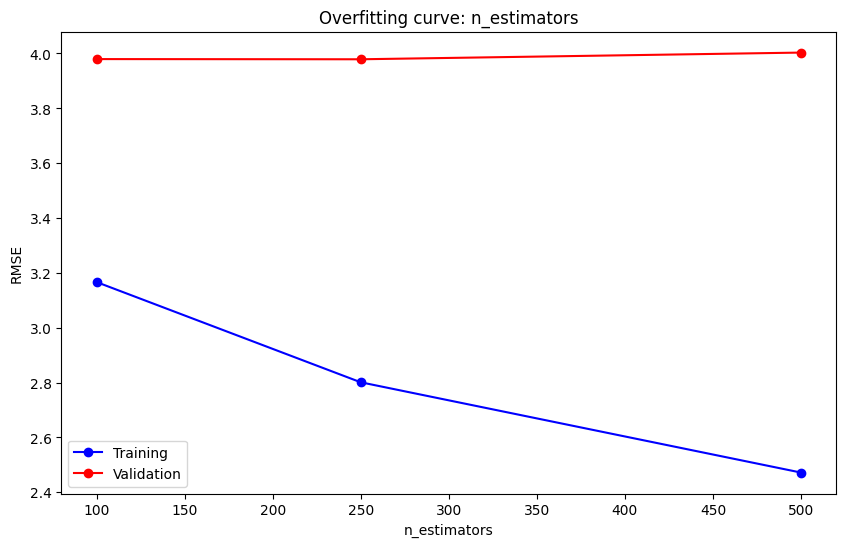

In [113]:
%%time

test_parameters_and_plot(XGBRegressor, "n_estimators", [100, 250, 500], **best_parameters)

Best number for estimators is 250

In [114]:
best_parameters["n_estimators"] = 250

### Max Depth

CPU times: total: 1min 17s
Wall time: 10.4 s


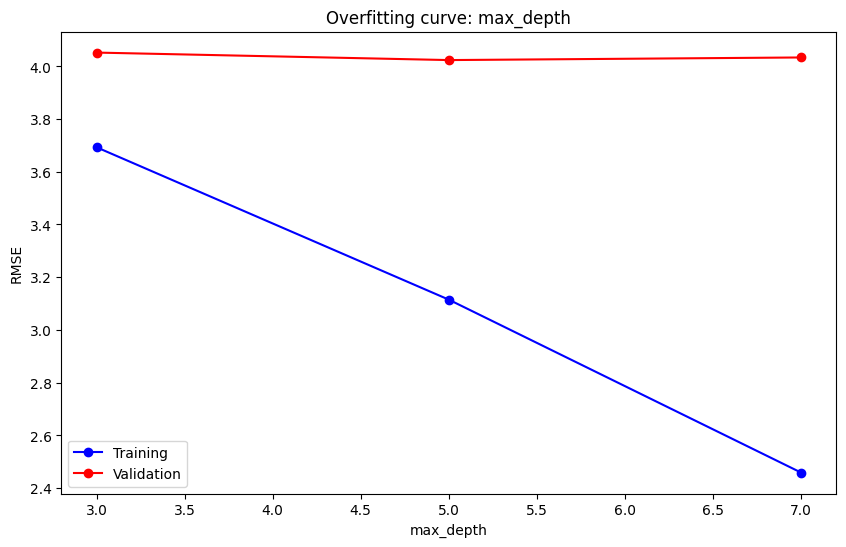

In [115]:
%%time

test_parameters_and_plot(XGBRegressor, "max_depth", [3, 5, 7], **best_parameters)

Best number for max_depth seems to be 7

In [116]:
best_parameters["max_depth"] = 7

### Learning Rate

CPU times: total: 1min 38s
Wall time: 13.9 s


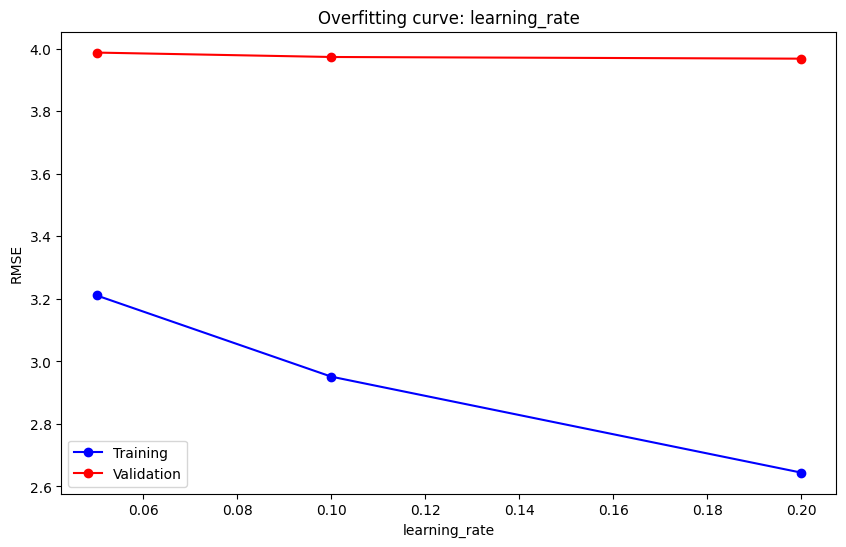

In [117]:
%%time

test_parameters_and_plot(XGBRegressor, "learning_rate", [0.05, 0.1, 0.2], **best_parameters)

The best number for learning rate is 0.20

In [118]:
best_parameters["learning_rate"] = 0.20

### Other Parameters

In [119]:
xgb_model_final = XGBRegressor(objective = "reg:squarederror", n_jobs = -1, random_state = 42,
                               n_estimators = 500, max_depth = 8, learning_rate = 0.2, 
                               subsample = 0.7, colsample_bytree= 0.7)

In [120]:
xgb_model_final.fit(train_inputs, train_target)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [121]:
evaluate(xgb_model_final)

(np.float64(2.019598541024116),
 np.float64(4.037046774354391),
 array([ 6.864814 ,  6.2358913, 10.07474  , ..., 12.22686  ,  9.763158 ,
         9.56135  ], shape=(431098,), dtype=float32),
 array([14.56568 ,  5.270528, 47.72701 , ...,  8.013155, 32.07627 ,
         8.557694], shape=(107742,), dtype=float32))

In [122]:
predict_and_submit(xgb_model_final, "Kaggle Submission/XGB_Model_Submission.csv")

,key,fare_amount
0,2015-01-27 13:08:24.0000002,10.562403
1,2015-01-27 13:08:24.0000003,10.746438
2,2011-10-08 11:53:44.0000002,3.979472
3,2012-12-01 21:12:12.0000002,9.090034
4,2012-12-01 21:12:12.0000003,15.831092
...,...,...
9909,2015-05-10 12:37:51.0000002,8.789367
9910,2015-01-12 17:05:51.0000001,10.772232
9911,2015-04-19 20:44:15.0000001,54.857697
9912,2015-01-31 01:05:19.0000005,19.202148


## 9. Create and Test Prediction Logic

In [123]:
from geopy.geocoders import Nominatim
from datetime import datetime

geolocator = Nominatim(user_agent="fare-predictor")

def get_coordinates(address):
    location = geolocator.geocode(address)
    if location:
        return location.longitude, location.latitude
    else:
        raise ValueError(f"Could not geocode address: {address}")

In [124]:
landmarks = {
    "jfk": (-73.7781, 40.6413),
    "lga": (-73.8740, 40.7769),
    "ewr": (-74.1745, 40.6895),
    "met": (-73.9632, 40.7794),
    "wtc": (-74.0099, 40.7126)
}

In [125]:
def compute_landmark_distances(dropoff_long, dropoff_lat):
    return {
        f"{name}_drop_distance": haversine_np(lon, lat, dropoff_long, dropoff_lat)
        for name, (lon, lat) in landmarks.items()
    }

In [126]:
def extract_datetime_features(pickup_datetime):
    return {
        "pickup_datetime_year": pickup_datetime.year,
        "pickup_datetime_month": pickup_datetime.month,
        "pickup_datetime_day": pickup_datetime.day,
        "pickup_datetime_weekday": pickup_datetime.weekday(),
        "pickup_datetime_hour": pickup_datetime.hour
    }

In [127]:
def preprocess_input(pickup_address, dropoff_address, passenger_count, pickup_datetime=None):
    if pickup_datetime is None:
        pickup_datetime = datetime.now()

    # Geocode
    pickup_long, pickup_lat = get_coordinates(pickup_address)
    dropoff_long, dropoff_lat = get_coordinates(dropoff_address)

    # Compute features
    trip_distance = haversine_np(pickup_long, pickup_lat, dropoff_long, dropoff_lat)
    landmark_distances = compute_landmark_distances(dropoff_long, dropoff_lat)
    datetime_features = extract_datetime_features(pickup_datetime)

    # Create dictionary of model inputs
    features = {
        "pickup_longitude": pickup_long,
        "pickup_latitude": pickup_lat,
        "dropoff_longitude": dropoff_long,
        "dropoff_latitude": dropoff_lat,
        "passenger_count": passenger_count,
        "trip_distance": trip_distance,
        **datetime_features,
        **landmark_distances
    }

    model_input_columns = [
    'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude',
    'passenger_count',
    'pickup_datetime_year', 'pickup_datetime_month', 'pickup_datetime_day',
    'pickup_datetime_weekday', 'pickup_datetime_hour',
    'trip_distance',
    'jfk_drop_distance', 'lga_drop_distance', 'ewr_drop_distance',
    'met_drop_distance', 'wtc_drop_distance'
    ]

    return pd.DataFrame([features])[model_input_columns]

In [128]:
pickup = input("Enter pickup location: ")
dropoff = input("Enter destination: ")
passengers = int(input("Enter number of passengers: "))

processed = preprocess_input(pickup, dropoff, passengers)
fare = model_3.predict(processed)[0]
print(f"Predicted Fare: ${fare:.2f}")

Enter pickup location:  Metlife
Enter destination:  Newark
Enter number of passengers:  1


Predicted Fare: $64.53


In [129]:
from taxi_fare_model import TaxiFareModel
import joblib

model_wrapper = TaxiFareModel(model_3)

joblib.dump(model_wrapper, 'model_3_wrapper.pkl')

['model_3_wrapper.pkl']

## Appendix
### Plans for the Future
#### 1. Improving Model Accuracy through Ensemble Learning
I believe the most accurate model will likely be achieved using Ensemble Learning techniques. In a future iteration, I plan to revisit this project and implement ensemble strategies such as bagging or stacking to outperform the current baseline model.

#### 2. Full Dataset Training on GPU
To enhance training effectiveness and model performance, I intend to train future models on the entire dataset using GPU acceleration. The current model was trained on only 1% of the data, primarily due to resource constraints. Leveraging GPU capabilities will allow for faster processing and better scalability.

https://towardsdatascience.com/nyc-taxi-fare-prediction-605159aa9c24

https://jovian.ai/allenkong221/nyc-taxi-fare-rapids-dask-gpu/v/1?utm_source=embed#C10